# 15장 실습 — 런타임 모니터·폴백·안전 필터

14장까지는 정책이 **성공하느냐**만 셌다. 이 노트북은 정책이 실패할 때 **무슨 일이 일어나느냐**를 센다. 그리고 정책 바깥에 세 층을 얹는다.

| 층 | 하는 일 | 이 노트북에서 |
|---|---|---|
| 런타임 모니터 | 정책이 모르는 상황을 알아챈다 | 시드 셋 정책의 행동 불일치 |
| 폴백 | 알아채면 제어를 넘긴다 | 관측으로 도는 대본 제어기, 또는 감속 |
| 안전 필터 | 금지된 명령을 막는다 | 작업대 끝으로 미는 명령을 0으로 |

사건은 둘이다. 1장의 **오배출**(부품이 반대 적재함에 들어간다)과, 이 장에서 새로 세는 **경계 이탈**(부품이 작업대 끝 x = 0.34 m 를 넘는다)이다. 경계 이탈은 비율과 넘어간 거리를 함께 적는다.

평가 조건은 12장이 찾은 문턱 근처다 — 배포, 편향 2배, 지연 2주기, 둘 다.

끝에서 `runtime/guard.json` 을 남긴다. 실행 시간은 CPU에서 5분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


## 정책 셋과 네 조건

7장의 행동 복제(시드 0)가 주 정책이다. 시드 1·2를 같은 데이터로 더 학습해 모니터에 쓴다(12장과 같은 설정).

In [8]:
XN = nz(XS)
BCS = [torch.load("policy/bc_v1.pt", weights_only=False)
       if os.path.exists("policy/bc_v1.pt") else bc(XN, YS, seed=0)]
BCS += [bc(XN, YS, seed=s) for s in (1, 2)]
XLIM = .34                               # 작업대 끝 (m)
COND.update({"편향 ×2": dict(bias=(.012, -.008), lat=1, mu=.8),
             "지연 2": dict(bias=(.006, -.004), lat=2, mu=.8),
             "편향 ×2 · 지연 2": dict(bias=(.012, -.008), lat=2,
                                    mu=.8)})
CONDS = ["배포", "편향 ×2", "지연 2", "편향 ×2 · 지연 2"]


def servo_obs(o):
    """관측만으로 도는 대본 제어기 — 1장의 대본과 같은 식"""
    gb, bp = o[:, 0:2] / 10., o[:, 4:6] / 10.
    dv = unit(gb)
    e = bp - dv * .045                   # 부품 뒤 지점까지
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)

## 세 층을 한 실행기에

모니터는 세 정책의 행동 표준편차(두 축 가운데 큰 것)가 문턱 τ 를 **세 스텝 연속** 넘으면 그 판에 깃발을 세운다. 깃발이 서면 그 판의 끝까지 폴백이 제어한다(개입 한 번). 안전 필터는 **관측한** 부품 위치가 작업대 끝에서 여유 m 안쪽이면 +x 명령을 0으로 만든다. 명령은 필터를 지난 뒤 조건의 지연을 거친다.

In [9]:
def guard(cond, tau=None, fb=None, margin=None, n=100, reps=2,
          seed=999, tag=0, ver="guard"):
    env = Pert(n, seed, **COND[cond])
    cnt, flag = np.zeros(n), np.zeros(n, bool)
    mx, dmax = np.zeros(n), np.zeros(n)
    rows, ev = [], []
    for t in range(EP * reps):
        o = env.obs()
        with torch.no_grad():
            A = np.stack([m.pi(torch.from_numpy(nz(o))).numpy()
                          for m in BCS])
        a, dis = A[0].copy(), A.std(0).max(1)
        dmax = np.maximum(dmax, dis)
        if tau is not None:
            cnt = np.where(dis > tau, cnt + 1, 0)
            flag |= cnt >= 3
            if fb == "script":
                a[flag] = servo_obs(o)[flag]
            elif fb == "slow":
                a[flag] *= .5
        if margin is not None:
            bx = env.g[:, 0] - o[:, 0] / 10.     # 관측한 부품 x
            a[:, 0] = np.where((bx > XLIM - margin) & (a[:, 0] > 0),
                               0., a[:, 0])
        bx = np.array([d.qpos[0] for d in env.d])
        mx = np.maximum(mx, bx)
        _, dn, sc = env.step(a.astype(np.float32))
        for i, sc_i in zip(np.flatnonzero(dn), sc):
            hit, wrong, steps, k = sc_i
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
            ev.append((hit, wrong, mx[i], int(flag[i]), dmax[i]))
        bx = np.array([d.qpos[0] for d in env.d])
        mx = np.where(dn > 0, bx, np.maximum(mx, bx))
        cnt[dn > 0], flag[dn > 0], dmax[dn > 0] = 0, False, 0.
    return rows, np.array(ev)


def summary(ev):
    ex = ev[:, 2] > XLIM
    over = np.maximum(ev[:, 2] - XLIM, 0) * 1e3
    return dict(success=ev[:, 0].mean(), wrong=int(ev[:, 1].sum()),
                exit=ex.mean(), p99=np.percentile(over, 99),
                max=over.max(), flag=ev[:, 3].mean(), n=len(ev))


def show(name, s, w=24):
    print(pad(name, w) + pad(f"{s['success']:.3f}", 8, True)
          + pad(f"{s['flag']:.1%}", 8, True)
          + pad(f"{s['exit']:.1%}", 8, True)
          + pad(f"{s['p99']:.0f}", 8, True)
          + pad(f"{s['max']:.0f}", 9, True)
          + pad(s["wrong"], 7, True))


HEAD = (pad("성공률", 8, True) + pad("개입률", 8, True)
        + pad("이탈률", 8, True) + pad("p99 mm", 8, True)
        + pad("최대 mm", 9, True) + pad("오배출", 7, True))

## 사건 — 층 없이

In [10]:
LOG, EV, BASE = [], [], {}
t0 = time.time()
print(pad("조건", 24) + HEAD)
for c in ["명목"] + CONDS:
    rows, ev = guard(c, ver="base")
    LOG.extend(rows)
    EV += [(c, "base", *e) for e in ev]
    BASE[c] = ev
    show(c, summary(ev))
print(f"({time.time() - t0:.0f}s)")

조건                      성공률  개입률  이탈률  p99 mm  최대 mm 오배출


명목                       1.000    0.0%    0.0%       0        0      0


배포                       0.971    0.0%    2.2%      16       50      0


편향 ×2                    0.902    0.0%    1.8%      32       65      0


지연 2                     0.596    0.0%    5.3%      63       83      0


편향 ×2 · 지연 2           0.495    0.0%    5.7%      60       69      0
(15s)


## 모니터 — 불일치는 실패를 예고하는가

판마다 불일치의 최댓값으로 실패를 가려내는 능력을 AUROC 로 잰다(0.5면 동전 던지기, 1이면 완벽). 그다음 명목 조건의 스텝별 불일치 분포에서 문턱 τ 를 고른다.

In [11]:
def auroc(score, fail):
    pos, neg = score[fail], score[~fail]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    gt = (pos[:, None] > neg[None, :]).mean()
    eq = (pos[:, None] == neg[None, :]).mean()
    return float(gt + .5 * eq)


for c in CONDS:
    ev = BASE[c]
    print(pad(c, 20) + f"AUROC {auroc(ev[:, 4], ev[:, 0] == 0):.3f}"
          f"  (실패 {int((ev[:, 0] == 0).sum())}판)")

env = Cell(100, 7)
D0 = []
for t in range(EP * 2):
    o = nz(env.obs())
    with torch.no_grad():
        A = np.stack([m.pi(torch.from_numpy(o)).numpy()
                      for m in BCS])
    D0.append(A.std(0).max(1))
    env.step(A[0])
D0 = np.concatenate(D0)
TAUS = {q: float(np.quantile(D0, q)) for q in (.99, .999, 1.)}
print()
for q, v in TAUS.items():
    print(f"명목 스텝 불일치의 {q:.1%} 분위  τ = {v:.3f}")

배포                AUROC 0.961  (실패 12판)
편향 ×2             AUROC 0.884  (실패 28판)
지연 2              AUROC 0.905  (실패 92판)
편향 ×2 · 지연 2    AUROC 0.746  (실패 107판)



명목 스텝 불일치의 99.0% 분위  τ = 0.118
명목 스텝 불일치의 99.9% 분위  τ = 0.148
명목 스텝 불일치의 100.0% 분위  τ = 0.172


## 폴백 — 누구에게 넘기는가

세 문턱과 두 폴백을 네 조건에서 잰다. **대본**은 관측만으로 도는 1장의 대본 제어기다 — 편향과 지연을 정책과 똑같이 겪는다. **감속**은 정책의 명령을 절반으로 줄인다.

In [12]:
FB = {}
t0 = time.time()
for q, tau in TAUS.items():
    for fb in ("script", "slow"):
        for c in CONDS:
            rows, ev = guard(c, tau=tau, fb=fb, ver=f"fb-{fb}-{q}")
            LOG.extend(rows)
            EV += [(c, f"fb-{fb}-{q}", *e) for e in ev]
            FB[(q, fb, c)] = summary(ev)
print(f"({time.time() - t0:.0f}s)")
for q in TAUS:
    for fb, nm in (("script", "대본"), ("slow", "감속")):
        print(f"\nτ = {q:.1%} 분위, 폴백 {nm}")
        print(pad("조건", 24) + HEAD)
        for c in CONDS:
            show(c, FB[(q, fb, c)])

(76s)

τ = 99.0% 분위, 폴백 대본
조건                      성공률  개입률  이탈률  p99 mm  최대 mm 오배출
배포                       0.998   65.1%    0.2%       0      112      0
편향 ×2                    0.985   97.2%    1.3%       3      149      0
지연 2                     0.815   92.4%    0.9%       0      228      0
편향 ×2 · 지연 2           0.800   99.5%    1.0%       0       47      0

τ = 99.0% 분위, 폴백 감속
조건                      성공률  개입률  이탈률  p99 mm  최대 mm 오배출
배포                       0.997   65.1%    0.0%       0        0      0
편향 ×2                    0.505   98.5%    2.9%       3       11      0
지연 2                     0.812   91.1%    0.5%       0        7      0
편향 ×2 · 지연 2           0.488   99.0%    0.0%       0        0      0

τ = 99.9% 분위, 폴백 대본
조건                      성공률  개입률  이탈률  p99 mm  최대 mm 오배출
배포                       0.979   24.5%    2.1%     196      225      0
편향 ×2                    0.939   76.9%    6.4%     139      263      0
지연 2                     0.859   60.7%    2.6%     131

## 대본 폴백이 부품을 밀어낸 판

τ = 99.9% 분위, 폴백 대본의 배포 조건에서 부품이 가장 멀리 넘어간 판을 따라간다. 깃발이 선 스텝 앞뒤를 두 스텝 간격으로 적는다.

In [13]:
def trace_worst(cond, tau, n=100, seed=999):
    env = Pert(n, seed, **COND[cond])
    cnt, flag = np.zeros(n), np.zeros(n, bool)
    hist, worst = [[] for _ in range(n)], (0., None)
    for t in range(EP * 2):
        o = env.obs()
        with torch.no_grad():
            A = np.stack([m.pi(torch.from_numpy(nz(o))).numpy()
                          for m in BCS])
        a, dis = A[0].copy(), A.std(0).max(1)
        cnt = np.where(dis > tau, cnt + 1, 0)
        flag |= cnt >= 3
        a[flag] = servo_obs(o)[flag]
        for i, d in enumerate(env.d):
            hist[i].append((env.t[i], flag[i], d.qpos[0], d.qpos[7],
                            env.g[i, 0], a[i, 0]))
        _, dn, _ = env.step(a.astype(np.float32))
        for i in np.flatnonzero(dn):
            h = np.array(hist[i])
            if h[:, 2].max() > worst[0]:
                worst = (h[:, 2].max(), h)
            hist[i], cnt[i], flag[i] = [], 0, False
    return worst[1]


h = trace_worst("배포", TAUS[.999])
f0 = int(np.argmax(h[:, 1] > 0))
print(f"깃발이 선 스텝 {h[f0, 0]:.0f},"
      f" 부품 x 최대 {h[:, 2].max():.3f} m")
for r in h[max(f0 - 6, 0):f0 + 14:2]:
    print(f"스텝 {r[0]:3.0f}  깃발 {'예' if r[1] else '—'}"
          f"  부품 x {r[2]:.3f}  밀대 x {r[3]:.3f}"
          f"  목표 x {r[4]:.3f}  명령 x {r[5]:+.2f}")

깃발이 선 스텝 53, 부품 x 최대 0.565 m
스텝  47  깃발 —  부품 x 0.329  밀대 x 0.287  목표 x 0.282  명령 x -0.26
스텝  49  깃발 —  부품 x 0.330  밀대 x 0.279  목표 x 0.282  명령 x +0.21
스텝  51  깃발 —  부품 x 0.330  밀대 x 0.279  목표 x 0.282  명령 x +0.30
스텝  53  깃발 예  부품 x 0.330  밀대 x 0.287  목표 x 0.282  명령 x +0.63
스텝  55  깃발 예  부품 x 0.339  밀대 x 0.298  목표 x 0.282  명령 x +0.63
스텝  57  깃발 예  부품 x 0.356  밀대 x 0.317  목표 x 0.282  명령 x +0.62
스텝  59  깃발 예  부품 x 0.375  밀대 x 0.337  목표 x 0.282  명령 x +0.61
스텝  61  깃발 예  부품 x 0.394  밀대 x 0.356  목표 x 0.282  명령 x +0.61
스텝  63  깃발 예  부품 x 0.413  밀대 x 0.376  목표 x 0.282  명령 x +0.60
스텝  65  깃발 예  부품 x 0.432  밀대 x 0.395  목표 x 0.282  명령 x +0.59


## 안전 필터 — 지연이 있으면 새는가

배포 조건의 편향과 마찰에 지연을 1·2·3주기로 바꾸며 여유 m 을 0에서 5 cm 까지 늘린다.

In [14]:
MARG = [None, 0., .01, .02, .03, .05]
SF = {}
t0 = time.time()
for lat in (1, 2, 3):
    COND["_f"] = dict(bias=(.006, -.004), lat=lat, mu=.8)
    for m in MARG:
        rows, ev = guard("_f", margin=m, ver=f"filter-{lat}-{m}")
        LOG.extend(rows)
        SF[(lat, m)] = summary(ev)
print(f"({time.time() - t0:.0f}s)\n")
print(pad("지연", 6) + pad("여유", 8) + pad("성공률", 8, True)
      + pad("이탈률", 8, True) + pad("p99 mm", 8, True)
      + pad("최대 mm", 9, True))
for (lat, m), s in SF.items():
    mm = "없음" if m is None else f"{m * 100:g} cm"
    print(pad(lat, 6) + pad(mm, 8)
          + pad(f"{s['success']:.3f}", 8, True)
          + pad(f"{s['exit']:.1%}", 8, True)
          + pad(f"{s['p99']:.0f}", 8, True)
          + pad(f"{s['max']:.0f}", 9, True))

(48s)

지연  여유      성공률  이탈률  p99 mm  최대 mm
1     없음       0.971    2.2%      16       50
1     0 cm       0.970    0.5%       0        7
1     1 cm       0.970    0.5%       0        3
1     2 cm       0.968    0.0%       0        0
1     3 cm       0.978    0.0%       0        0
1     5 cm       0.970    0.0%       0        0
2     없음       0.596    5.3%      63       83
2     0 cm       0.596    1.8%      16       20
2     1 cm       0.594    0.9%       0       13
2     2 cm       0.594    0.9%       0        9
2     3 cm       0.599    0.4%       0        1
2     5 cm       0.590    0.0%       0        0
3     없음       0.158    0.0%       0        0
3     0 cm       0.158    0.0%       0        0
3     1 cm       0.158    0.0%       0        0
3     2 cm       0.158    0.0%       0        0
3     3 cm       0.158    0.0%       0        0
3     5 cm       0.158    0.0%       0        0


## 세 층을 함께

모니터(τ = 명목 99.9% 분위), 폴백(대본), 안전 필터(여유 2 cm)를 한꺼번에 얹는다. 명목 조건도 함께 재서 헛경보가 얼마나 되는지 본다. 시드 셋으로 잰다.

In [15]:
ALL = {}
t0 = time.time()
for c in ["명목"] + CONDS:
    evs = []
    for s in range(3):
        rows, ev = guard(c, tau=TAUS[.999], fb="script", margin=.02,
                         seed=999 + s, tag=s, ver="guard-all")
        LOG.extend(rows)
        EV += [(c, "guard-all", *e) for e in ev]
        evs.append(ev)
    ALL[c] = summary(np.concatenate(evs))
print(f"({time.time() - t0:.0f}s)\n")
print(pad("조건", 30) + HEAD)
for c in ["명목"] + CONDS:
    show(c + " · 층 없음", summary(BASE[c]), 30)
    show(c + " · 세 층", ALL[c], 30)

(45s)

조건                            성공률  개입률  이탈률  p99 mm  최대 mm 오배출
명목 · 층 없음                   1.000    0.0%    0.0%       0        0      0
명목 · 세 층                     1.000    0.1%    0.0%       0        0      0
배포 · 층 없음                   0.971    0.0%    2.2%      16       50      0
배포 · 세 층                     0.970   30.1%    0.1%       0        0      0
편향 ×2 · 층 없음                0.902    0.0%    1.8%      32       65      0
편향 ×2 · 세 층                  0.916   75.4%    1.4%       0       15      2
지연 2 · 층 없음                 0.596    0.0%    5.3%      63       83      0
지연 2 · 세 층                   0.865   63.2%    0.6%       0        8      0
편향 ×2 · 지연 2 · 층 없음       0.495    0.0%    5.7%      60       69      0
편향 ×2 · 지연 2 · 세 층         0.640   92.6%    0.5%       0       10      0


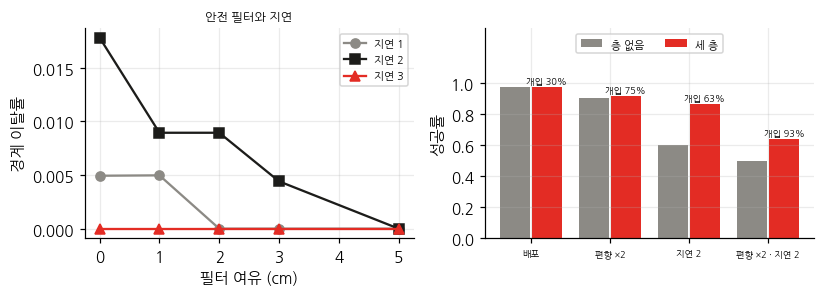

In [16]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.6, 2.8))
for lat, col, mk in ((1, GREY, "o"), (2, INK, "s"), (3, RED, "^")):
    xs = [m * 100 for m in MARG[1:]]
    a1.plot(xs, [SF[(lat, m)]["exit"] for m in MARG[1:]], color=col,
            marker=mk, label=f"지연 {lat}")
a1.set_xlabel("필터 여유 (cm)")
a1.set_ylabel("경계 이탈률")
a1.legend(fontsize=7)
a1.set_title("안전 필터와 지연", fontsize=8)
x = np.arange(len(CONDS))
a2.bar(x - .2, [summary(BASE[c])["success"] for c in CONDS], .38,
       color=GREY, label="층 없음")
a2.bar(x + .2, [ALL[c]["success"] for c in CONDS], .38, color=RED,
       label="세 층")
for i, c in enumerate(CONDS):
    a2.text(i + .2, ALL[c]["success"] + .02,
            f"개입 {ALL[c]['flag']:.0%}", ha="center", fontsize=6)
a2.set_xticks(x, CONDS, fontsize=6)
a2.set_ylim(0, 1.35)
a2.set_yticks([0, .2, .4, .6, .8, 1.])
a2.set_ylabel("성공률")
a2.legend(fontsize=7, loc="upper center", ncol=2)
plt.tight_layout()
plt.show()

## 산출물

1장의 로그 스키마(7열)에는 경계 이탈을 적을 열이 없다. 판별 로그는 스키마 그대로 남기고, 경계 이탈 거리는 `runtime/guard_events.csv` 에 따로 남긴다.

In [17]:
rnd = lambda s: {k: (round(float(v), 4) if isinstance(v, float)
                     else v) for k, v in s.items()}
out = {"xlim": XLIM, "tau": TAUS,
       "base": {c: rnd(summary(BASE[c])) for c in BASE},
       "fallback": {f"{q}-{fb}-{c}": rnd(s)
                    for (q, fb, c), s in FB.items()},
       "filter": {f"lat{l}-{m}": rnd(s)
                  for (l, m), s in SF.items()},
       "all_layers": {c: rnd(s) for c, s in ALL.items()}}
os.makedirs("runtime", exist_ok=True)
with open("runtime/guard.json", "w") as f:
    json.dump(out, f, ensure_ascii=False, indent=1)
with open("runtime/guard_events.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["cond", "version", "success", "wrong", "max_x",
                "flag", "max_dis"])
    w.writerows(EV)
save_log("report/ch15_log.csv", LOG)
print("runtime/guard.json, runtime/guard_events.csv 저장")
print(f"report/ch15_log.csv  판별 로그 {len(LOG):,}줄")

runtime/guard.json, runtime/guard_events.csv 저장
report/ch15_log.csv  판별 로그 17,910줄
